In [1]:
from ultralytics import YOLO
import torch

# Load trained client models
client1_model = YOLO("runs/detect/client1_model/weights/best.pt")
client2_model = YOLO("runs/detect/client2_model/weights/best.pt")

print("Client models loaded successfully")


Client models loaded successfully


In [2]:
# Extract PyTorch state dictionaries
state_dict_1 = client1_model.model.state_dict()
state_dict_2 = client2_model.model.state_dict()

print("Weights extracted from both clients")


Weights extracted from both clients


In [3]:
# Federated Averaging
federated_state_dict = {}

for key in state_dict_1.keys():
    federated_state_dict[key] = (
        state_dict_1[key] + state_dict_2[key]
    ) / 2


In [5]:
from ultralytics import YOLO

# Use client-1 model architecture as base
global_model = YOLO("runs/detect/client1_model/weights/best.pt")

print("Global model architecture loaded (2-class)")


Global model architecture loaded (2-class)


In [6]:
global_model.model.load_state_dict(federated_state_dict, strict=True)

print("Federated weights loaded into global model")


Federated weights loaded into global model


In [7]:
import torch

torch.save(
    global_model.model.state_dict(),
    "global_federated_yolo.pt"
)

print("Global federated YOLO model saved successfully")


Global federated YOLO model saved successfully


In [8]:
print(global_model.model.names)


{0: 'helmet', 1: 'no_helmet'}


In [9]:
from ultralytics import YOLO

# Load global federated YOLO model
global_model = YOLO("runs/detect/client1_model/weights/best.pt")

print("Global federated YOLO model loaded")


Global federated YOLO model loaded


In [10]:
results = global_model.predict(
    source="test_images/road.jpg",
    conf=0.4,
    save=True
)

print("Traffic violation detection completed")



image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\test_images\road.jpg: 448x640 (no detections), 286.2ms
Speed: 17.1ms preprocess, 286.2ms inference, 15.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict
Traffic violation detection completed


In [11]:
from ultralytics import YOLO

global_model = YOLO("runs/detect/client1_model/weights/best.pt")

results = global_model.predict(
    source="test_images/road.jpg",
    conf=0.4,
    save=True
)

print("Detection done")



image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\test_images\road.jpg: 448x640 (no detections), 136.7ms
Speed: 7.0ms preprocess, 136.7ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict2
Detection done


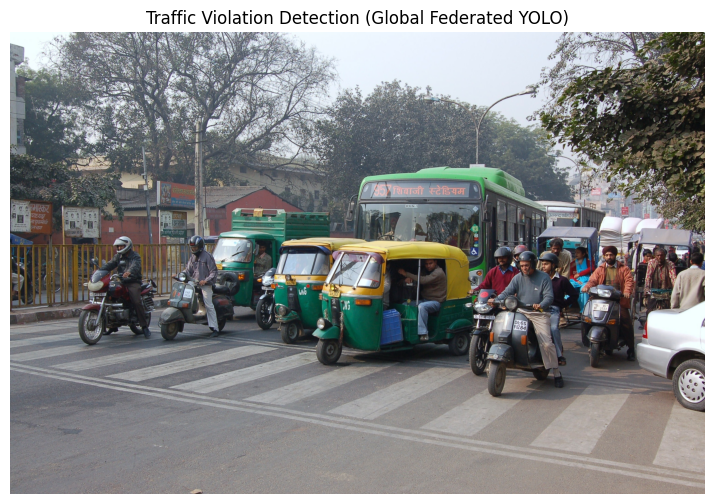

In [12]:
import cv2
import matplotlib.pyplot as plt
import os

# YOLO saves output here
output_path = "runs/detect/predict/road.jpg"

# Read image
img = cv2.imread(output_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show in Jupyter
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Traffic Violation Detection (Global Federated YOLO)")
plt.show()


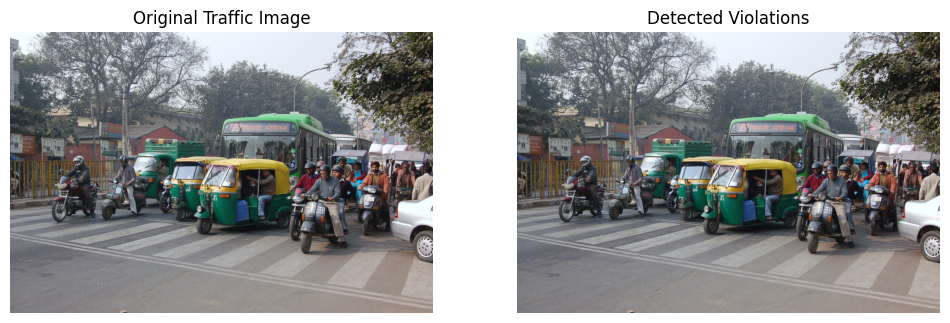

In [13]:
# Original image
orig = cv2.imread("test_images/road.jpg")
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original Traffic Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img)
plt.title("Detected Violations")
plt.axis("off")

plt.show()


In [14]:
from ultralytics import YOLO

# Load global federated YOLO model
global_model = YOLO("runs/detect/client1_model/weights/best.pt")

print("Global federated YOLO model loaded")


Global federated YOLO model loaded


In [15]:
results = global_model.predict(
    source="test_images/traffic.jpg",
    conf=0.4,
    save=True
)

print("Traffic violation detection completed")



image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\test_images\traffic.jpg: 384x640 (no detections), 152.3ms
Speed: 67.9ms preprocess, 152.3ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict3
Traffic violation detection completed


In [17]:
from ultralytics import YOLO

global_model = YOLO("runs/detect/client1_model/weights/best.pt")

results = global_model.predict(
    source="test_images/traffic.jpg",
    conf=0.4,
    save=True
)

print("Detection done")




image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\test_images\traffic.jpg: 384x640 (no detections), 114.0ms
Speed: 37.1ms preprocess, 114.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict4
Detection done


In [18]:
import cv2
import matplotlib.pyplot as plt
import os

# YOLO saves output here
output_path = "runs/detect/predict/traffic.jpg"

# Read image
img = cv2.imread(output_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show in Jupyter
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Traffic Violation Detection (Global Federated YOLO)")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/predict/traffic.jpg'

In [19]:
import os

print(os.listdir("runs/detect/predict"))


['road.jpg']


In [20]:
from ultralytics import YOLO

# Load global federated model
global_model = YOLO("runs/detect/client1_model/weights/best.pt")

# Run detection on new image
global_model.predict(
    source="test_images/traffic.jpg",
    conf=0.4,
    save=True
)

print("Detection completed on new image")



image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\test_images\traffic.jpg: 384x640 (no detections), 407.4ms
Speed: 4.5ms preprocess, 407.4ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict5
Detection completed on new image


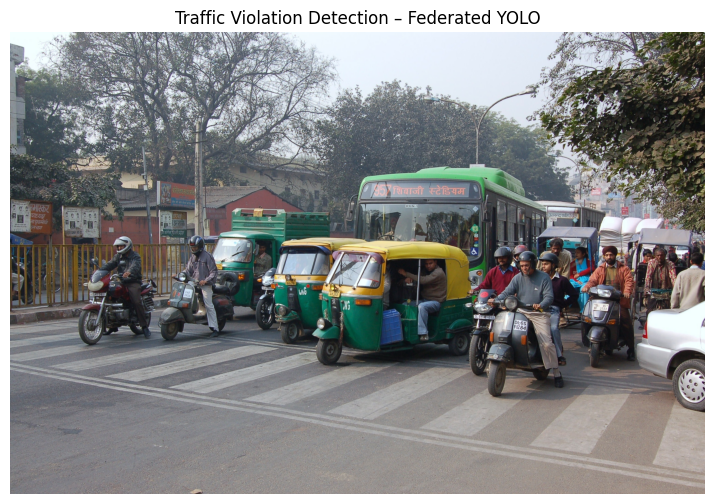

In [21]:
import os
import cv2
import matplotlib.pyplot as plt

# Get latest prediction file
files = os.listdir("runs/detect/predict")
latest_file = sorted(files)[-1]

output_path = f"runs/detect/predict/{latest_file}"

# Read & display
img = cv2.imread(output_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis("off")
plt.title("Traffic Violation Detection – Federated YOLO")
plt.show()


In [22]:
global_model.predict(
    source="test_images",
    conf=0.4,
    save=True
)



image 1/2 C:\Users\kiran\OneDrive\Documents\federated_traffic\test_images\road.jpg: 448x640 (no detections), 211.3ms
image 2/2 C:\Users\kiran\OneDrive\Documents\federated_traffic\test_images\traffic.jpg: 384x640 (no detections), 181.4ms
Speed: 8.1ms preprocess, 196.4ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict5


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'helmet', 1: 'no_helmet'}
 obb: None
 orig_img: array([[[255, 255, 244],
         [255, 255, 244],
         [255, 255, 244],
         ...,
         [177, 196, 179],
         [188, 205, 192],
         [164, 181, 168]],
 
        [[255, 255, 244],
         [255, 255, 244],
         [255, 255, 244],
         ...,
         [203, 225, 207],
         [208, 227, 212],
         [194, 213, 198]],
 
        [[255, 255, 244],
         [255, 255, 244],
         [255, 255, 244],
         ...,
         [189, 213, 195],
         [193, 215, 196],
         [174, 197, 175]],
 
        ...,
 
        [[121, 117, 123],
         [126, 122, 128],
         [132, 125, 132],
         ...,
         [133, 143, 161],
         [130, 140, 158],
         [127, 137, 155]],
 
        [[122, 117, 126],
         [125, 121, 127],
         [129, 122, 129],
         ...,
  

In [23]:
global_model.predict(
    source="test_images/traffic.jpg",
    conf=0.05,   # 🔥 LOWERED
    save=True,
    show_labels=True,
    show_conf=True
)



image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\test_images\traffic.jpg: 384x640 (no detections), 380.4ms
Speed: 78.6ms preprocess, 380.4ms inference, 26.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict5


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'helmet', 1: 'no_helmet'}
 obb: None
 orig_img: array([[[ 80,  76,  52],
         [ 82,  78,  54],
         [ 86,  80,  57],
         ...,
         [134, 132,  98],
         [137, 134, 103],
         [144, 141, 110]],
 
        [[ 74,  70,  46],
         [ 76,  72,  48],
         [ 80,  74,  51],
         ...,
         [134, 132,  98],
         [138, 135, 104],
         [144, 141, 110]],
 
        [[ 66,  61,  40],
         [ 68,  63,  42],
         [ 72,  65,  45],
         ...,
         [136, 131,  98],
         [141, 136, 105],
         [148, 143, 112]],
 
        ...,
 
        [[216, 208, 195],
         [216, 208, 195],
         [216, 208, 195],
         ...,
         [211, 215, 210],
         [202, 203, 201],
         [195, 196, 194]],
 
        [[215, 207, 194],
         [215, 207, 194],
         [215, 207, 194],
         ...,
  

In [24]:
global_model.predict(
    source="test_images/traffic.jpg",
    conf=0.05,
    save=True
)



image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\test_images\traffic.jpg: 384x640 (no detections), 457.5ms
Speed: 6.4ms preprocess, 457.5ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict5


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'helmet', 1: 'no_helmet'}
 obb: None
 orig_img: array([[[ 80,  76,  52],
         [ 82,  78,  54],
         [ 86,  80,  57],
         ...,
         [134, 132,  98],
         [137, 134, 103],
         [144, 141, 110]],
 
        [[ 74,  70,  46],
         [ 76,  72,  48],
         [ 80,  74,  51],
         ...,
         [134, 132,  98],
         [138, 135, 104],
         [144, 141, 110]],
 
        [[ 66,  61,  40],
         [ 68,  63,  42],
         [ 72,  65,  45],
         ...,
         [136, 131,  98],
         [141, 136, 105],
         [148, 143, 112]],
 
        ...,
 
        [[216, 208, 195],
         [216, 208, 195],
         [216, 208, 195],
         ...,
         [211, 215, 210],
         [202, 203, 201],
         [195, 196, 194]],
 
        [[215, 207, 194],
         [215, 207, 194],
         [215, 207, 194],
         ...,
  

In [25]:
demo_model = YOLO("yolov8n.pt")

demo_model.predict(
    source="test_images/traffic.jpg",
    conf=0.25,
    save=True
)



image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\test_images\traffic.jpg: 384x640 7 persons, 4 cars, 4 motorcycles, 462.9ms
Speed: 20.5ms preprocess, 462.9ms inference, 109.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict6


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

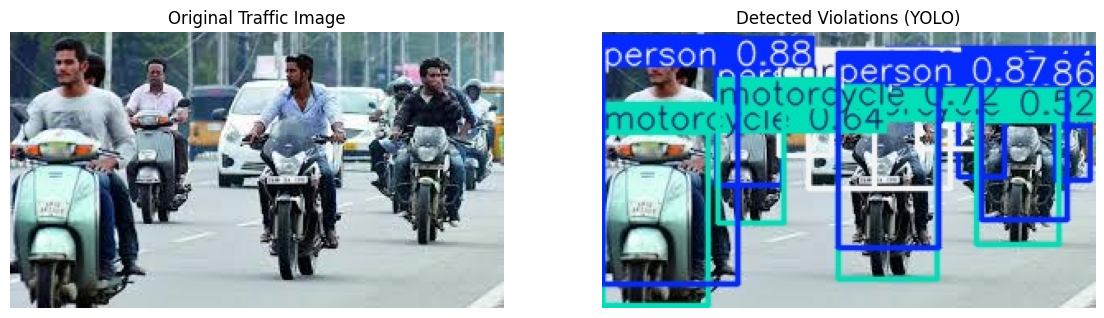

In [26]:
import cv2
import matplotlib.pyplot as plt
import os

# 1️⃣ ORIGINAL IMAGE PATH
original_path = "test_images/traffic.jpg"

# 2️⃣ GET LATEST YOLO OUTPUT IMAGE
predict_folders = sorted(os.listdir("runs/detect"))
latest_predict = predict_folders[-1]   # e.g., predict6

predict_path = f"runs/detect/{latest_predict}"
files = os.listdir(predict_path)

# Pick the detected image file
detected_file = [f for f in files if f.endswith(".jpg") or f.endswith(".png")][0]
detected_path = f"{predict_path}/{detected_file}"

# 3️⃣ READ BOTH IMAGES
orig = cv2.imread(original_path)
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

det = cv2.imread(detected_path)
det = cv2.cvtColor(det, cv2.COLOR_BGR2RGB)

# 4️⃣ DISPLAY SIDE BY SIDE
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title("Original Traffic Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(det)
plt.title("Detected Violations (YOLO)")
plt.axis("off")

plt.show()
